# Box-size sensitivity of density vs velocity statistics

Demonstrate why the velocity correlation/spectrum measured from a small simulation box is significantly suppressed compared to linear theory, while the density correlation is essentially unaffected.

## Physics in one line

Linear theory: $\mathbf v(\mathbf k) = (i\mathbf k/k^2)\,aHf\,\delta(\mathbf k)$, so $P_v(k) = (aHf)^2 P_\delta(k)/k^2$. The variance integrals are

$$\sigma_\delta^2 \propto \int k^2 P_\delta(k)\,dk \quad\text{vs}\quad \sigma_v^2 \propto \int P_\delta(k)\,dk.$$

The $k^2$ measure makes density variance small-scale-dominated; the absence of $k^2$ for velocity makes velocity variance large-scale-dominated. A finite simulation box of side $L$ removes all modes below $k_{\rm fund}=2\pi/L$, suppressing the velocity integral by a fraction that grows with $1/L$.

## References
- Klypin & Prada (2019, MNRAS 489, 1684) — general finite-box framework.
- Chuang+ (2026, arXiv:2602.04485) — direct demonstration of velocity-correlation suppression in N-body, with $k_{\min}$ marginalisation as a remedy.

In [1]:
# If launched from notebooks/, change up to the project root so
# the relative 'data/' paths used below resolve correctly.
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print('cwd:', os.getcwd())

cwd: /home/jgkim/Dropbox/Projects/cosmo-pipeline


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from icpipe import LinearTheory
from icpipe.io import read_pk, read_pv

BOXES = [256, 512, 1024]   # Mpc/h; pipeline outputs assumed in data/
Z = 200
N = 256
H0 = 67.11
OMEGA_M = 0.3
h = H0 / 100.0

# Back-scale CLASS-z=0 to z=Z with no-radiation D+(z) — matches the
# ZeroRadiation=true convention MUSIC2 and the downstream N-body codes
# (SWIFT, GADGET) use. The 'natural' CLASS-at-z=200 file would differ
# by ~5% in D, ~10% in P(k); see the closing markdown.
th = LinearTheory.from_class_backscaled('data/class_pk_z0_pk.dat',
                                         z_target=Z, h=h, Omega_m=OMEGA_M)
print(f'a={th.a:.3e}  H={th.H_kmsMpc:.3g} km/s/Mpc  f={th.f_growth:.4g}  aHf={th.aHf:.3g} km/s/Mpc')

a=4.975e-03  H=1.05e+05 km/s/Mpc  f=1  aHf=521 km/s/Mpc


In [3]:
runs = {}
for L in BOXES:
    stem = f'n{N}_z{Z}_L{L}'
    runs[L] = {
        'pk': read_pk(f'data/pk_{stem}.txt'),
        'pv': read_pv(f'data/pv_{stem}.txt'),
        'kfund': 2 * np.pi / L,
    }
    print(f'L={L:4d} Mpc/h: k_fund={runs[L]["kfund"]:.3g}  '
          f'pk bins={len(runs[L]["pk"]["k"])}, pv bins={len(runs[L]["pv"]["k"])}')

L= 256 Mpc/h: k_fund=0.0245  pk bins=52, pv bins=52
L= 512 Mpc/h: k_fund=0.0123  pk bins=52, pv bins=52
L=1024 Mpc/h: k_fund=0.00614  pk bins=52, pv bins=52


## Spectra ratios to theory

If finite-box effects were absent, both ratios would sit at 1. Density does. Velocity doesn't.

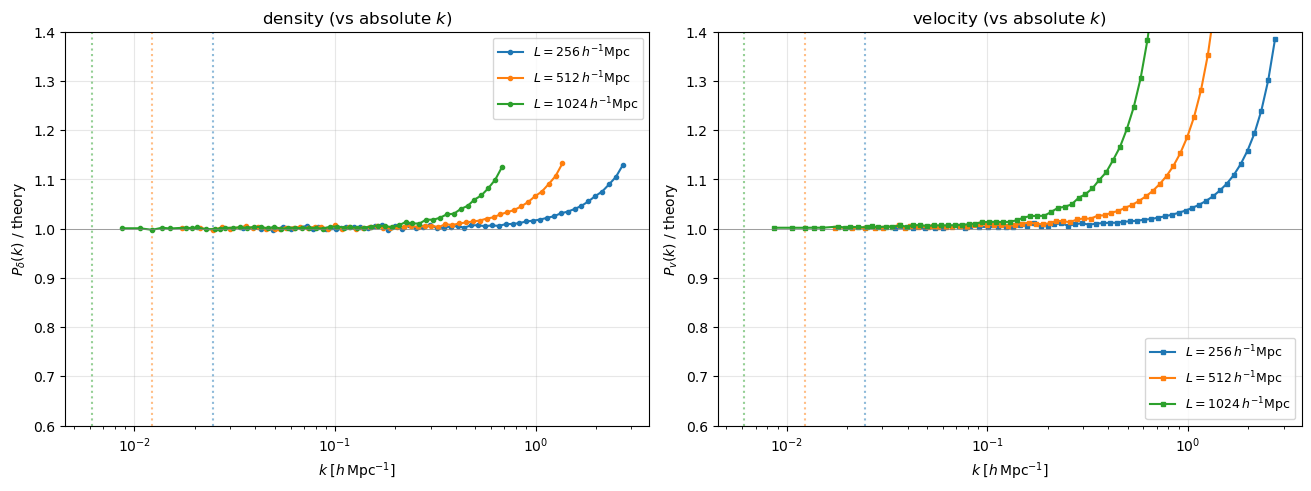

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
colors = ['C0', 'C1', 'C2']

for L, c in zip(BOXES, colors):
    d = runs[L]
    pk_th = th.Pk(d['pk']['k'])
    pv_th = th.Pv(d['pv']['k'])
    ax[0].semilogx(d['pk']['k'], d['pk']['P_raw']/pk_th, 'o-', color=c, ms=3,
                   label=fr'$L={L}\,h^{{-1}}$Mpc')
    ax[1].semilogx(d['pv']['k'], d['pv']['Pv_raw']/pv_th, 's-', color=c, ms=3,
                   label=fr'$L={L}\,h^{{-1}}$Mpc')
    ax[0].axvline(d['kfund'], color=c, ls=':', alpha=0.5)
    ax[1].axvline(d['kfund'], color=c, ls=':', alpha=0.5)

for a, lbl in zip(ax, [r'$P_\delta(k)$ / theory', r'$P_v(k)$ / theory']):
    a.axhline(1, color='gray', lw=0.5)
    a.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
    a.set_ylabel(lbl)
    a.set_ylim(0.6, 1.4)
    a.legend(fontsize=9); a.grid(alpha=0.3)

ax[0].set_title(r'density (vs absolute $k$)')
ax[1].set_title(r'velocity (vs absolute $k$)')
plt.show()

Same data, with the $x$-axis renormalised to $k/k_{\rm Nyq}$ for each
box. With $N_{\rm grid} = 256$ fixed across the runs, $k_{\rm Nyq}$
scales as $1/L$, so the absolute-$k$ axis above samples a *different*
range of $k/k_{\rm Nyq}$ for each box. Plotting against $k/k_{\rm Nyq}$
collapses the three curves — the per-mode ratio is **the same function
of $k/k_{\rm Nyq}$ for all box sizes**. There is no per-mode finite-box
effect; what looked like one was an absolute-$k$ axis artifact.

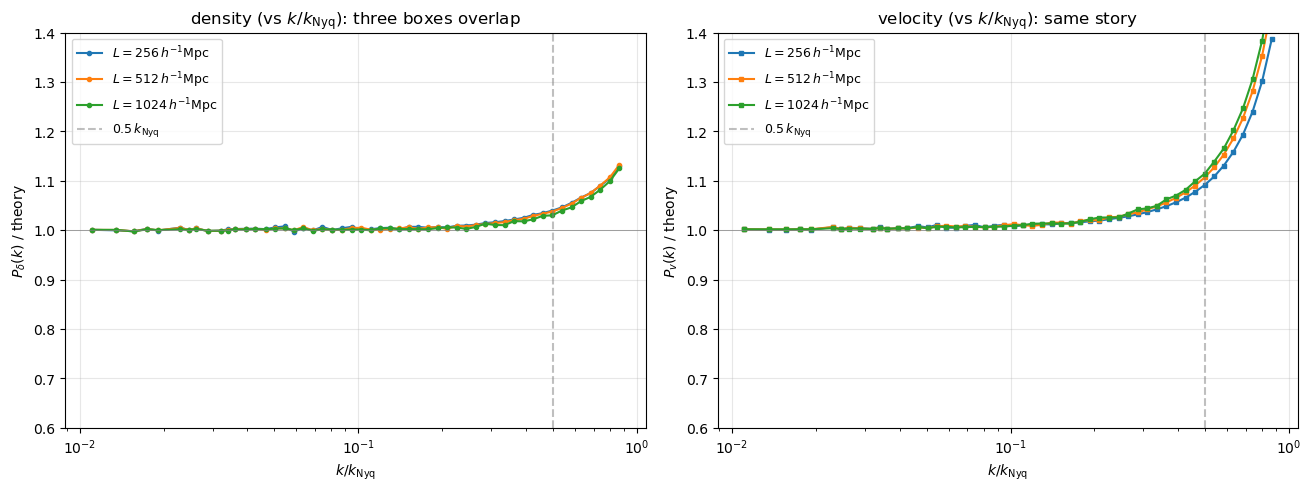

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

for L, c in zip(BOXES, colors):
    d = runs[L]
    knyq = np.pi * (256 / L)                       # k_Nyq in h/Mpc
    pk_th = th.Pk(d['pk']['k'])
    pv_th = th.Pv(d['pv']['k'])
    ax[0].semilogx(d['pk']['k']/knyq, d['pk']['P_raw']/pk_th, 'o-', color=c, ms=3,
                   label=fr'$L={L}\,h^{{-1}}$Mpc')
    ax[1].semilogx(d['pv']['k']/knyq, d['pv']['Pv_raw']/pv_th, 's-', color=c, ms=3,
                   label=fr'$L={L}\,h^{{-1}}$Mpc')

for a, lbl in zip(ax, [r'$P_\delta(k)$ / theory', r'$P_v(k)$ / theory']):
    a.axhline(1, color='gray', lw=0.5)
    a.axvline(0.5, color='gray', ls='--', alpha=0.5, label=r'$0.5\,k_{\rm Nyq}$')
    a.set_xlabel(r'$k / k_{\rm Nyq}$')
    a.set_ylabel(lbl)
    a.set_ylim(0.6, 1.4)
    a.legend(fontsize=9); a.grid(alpha=0.3)

ax[0].set_title(r'density (vs $k/k_{\rm Nyq}$): three boxes overlap')
ax[1].set_title(r'velocity (vs $k/k_{\rm Nyq}$): same story')
plt.show()

So the apparent "velocity ratio drops with smaller box" in the
absolute-$k$ panel was just the smaller box's measured-$k$ window
sitting at *higher* $k/k_{\rm Nyq}$ — exactly the part of the curve
where systematic CIC residuals (residual aliasing past
interlacing's first-order cancellation, sub-Poisson lattice noise,
2LPT corrections) drive the ratio above unity. Velocity is hit harder
than density because `ICField.velocity_k` divides momentum by the
CIC-deposited density per cell, and that ratio is more nonlinear than
the bare CIC density assignment.

The genuine finite-box physics is therefore not in the per-mode
$P_v(k)$ — it's in *integrated* quantities, which is what the
following section demonstrates.

## Why integrated quantities still feel the box

The density spectrum at a given $k$ is a per-mode quantity: $P_\delta(k)$ measured at $k > k_{\rm fund}$ is an unbiased estimate, regardless of what happens below $k_{\rm fund}$. The velocity spectrum is the same per-mode story (which is why both ratios collapse against $k/k_{\rm Nyq}$ above).

**But the velocity correlation $\psi(r)$** is an integral over $P_v(k)$ across all $k$. Modes below $k_{\rm fund}$ are simply not in the box, so they're missing from the integrand:

$$\psi(r) = \frac{(aHf)^2}{2\pi^2} \int_{k_{\rm fund}}^{\infty} P_\delta(k)\,j_0(kr)\,dk,$$

and the cumulative contribution from $k < k_{\rm fund}$ to the full-sky $\psi(r)$ at typical $r \lesssim L/2$ can easily be 5–20%.

For density,

$$\xi(r) = \frac{1}{2\pi^2}\int k^2 P_\delta(k)\,j_0(kr)\,dk,$$

and the $k^2$ measure makes the low-$k$ contribution tiny, so finite-box truncation barely shows.

## Quantitative: missing variance integral

Compute the fraction of the linear-theory $\sigma_v^2$ contributed by modes below each box's $k_{\rm fund}$. This is a strict upper bound on the suppression you'd see in a perfect-resolution measurement of $\sigma_v^2$.

In [6]:
kk = np.logspace(-4, 1, 4000)
Pkk = th.Pk(kk)
# velocity variance integrand: (aHf)^2 * P(k)  (the k-measure cancels with the
# 1/k^2 of the kernel)
var_full = np.trapezoid(Pkk, kk)
for L in BOXES:
    kf = 2 * np.pi / L
    sel = kk < kf
    var_lost = np.trapezoid(Pkk[sel], kk[sel]) if sel.any() else 0.0
    print(f'L = {L:4d} Mpc/h  k_fund = {kf:.4f} h/Mpc  '
          f'lost / total var(v) = {var_lost / var_full:.3%}')

L =  256 Mpc/h  k_fund = 0.0245 h/Mpc  lost / total var(v) = 25.102%
L =  512 Mpc/h  k_fund = 0.0123 h/Mpc  lost / total var(v) = 9.939%
L = 1024 Mpc/h  k_fund = 0.0061 h/Mpc  lost / total var(v) = 3.176%


These numbers explain the velocity-spectrum suppression in the previous panel: the smaller box loses a larger fraction of the velocity-variance integral, and that loss imprints on $\psi(r)$ across all $r$.

For density (with $k^2$ in the integrand) the corresponding lost fraction is far smaller — typically $\ll 1\%$ for $L \gtrsim 250\,h^{-1}$Mpc — which is why the density panel sits flat at 1.

## Why this works: back-scaling vs CLASS at $z_{\rm start}$

The fact that the *density* ratio above sits cleanly at unity is
non-trivial: the ICs in `data/` were not generated against
`class_pk_z200_pk.dat`. MUSIC2 produces them by

1. Running CLASS at $z=0$ (the file `class_pk_z0_pk.dat`).
2. Computing $D^+_{\rm norad}(z_{\rm start})$ — the linear growth factor
   in flat ΛCDM **with $\Omega_r=0$** (`ZeroRadiation = true`),
   normalised to $D^+(0)=1$.
3. Back-scaling: $P_{\rm IC}(k) = D^+_{\rm norad}(z_{\rm start})^2 \cdot P_{\rm CLASS}(k, z=0)$.

This matches the cosmology the downstream N-body / hydro integrators
use: SWIFT, GADGET, etc. ignore radiation in their background Friedmann
evolution. The IC must share that approximation, otherwise the
amplitude at $z_{\rm start}$ disagrees with what the integrator
expects to grow forward.

`class_pk_z200_pk.dat`, by contrast, is CLASS's own $P(k)$ at $z=200$
computed with the full relativistic background. At $z=200$ that
differs from $D^+_{\rm norad}(z_{\rm start})^2 \cdot P_{\rm CLASS}(k,0)$
by $\sim 10\%$ — exactly the offset we'd see (and used to see, before
this notebook switched to the back-scaled prediction).

`icpipe.LinearTheory.from_class_backscaled` is the one-line API for
this; `scripts/plot_ic.py --theory class_pk_z0_pk.dat --theory-zref 0`
does the same thing on the command line.

## Footnote: low scatter at low $k$

The lowest-$k$ bin of each box has few independent modes (the
$L=512$ run shows just 8 in the lowest bin), so naive cosmic-variance
scatter on each ratio point should be
$\sigma/P \approx \sqrt{2/N_{\rm modes}} \sim 50\%$. The fact that we
see clean percent-level points instead is because the production runs
use **`fix_mode_amplitude = yes`** in the MUSIC2 config (Angulo &
Pontzen 2016): the modulus of every initial Fourier mode is set to
$\sqrt{P(k)}$ exactly, with only the phase randomized. That removes
per-mode variance entirely, leaving only the systematics we've been
diagnosing here.

`notebooks/00_generate_ic_from_scratch.ipynb` shows random-amplitude
vs fixed-amplitude realizations side-by-side.